In [23]:
# ======================================================================
# PHASE 1: DATA ACQUISITION & INGESTION
# ======================================================================
import zipfile
import os
import pandas as pd

zip_path = "/content/sms+spam+collection.zip"
extract_path = "/content/sms_spam_data"

# Safely extract files
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

file_path = os.path.join(extract_path, "SMSSpamCollection")

# Load TSV format dataset
df = pd.read_csv(
    file_path,
    sep="\t",
    names=["label", "message"],
    encoding="utf-8"
)

# Save clean master copy
df.to_csv("/content/sms_spam_dataset.csv", index=False)

print(f"Dataset successfully loaded and saved to '/content/sms_spam_dataset.csv'")
print(f"Data Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Class Distribution Overview:")
print(df["label"].value_counts())

Dataset successfully loaded and saved to '/content/sms_spam_dataset.csv'
Data Shape: 5572 rows, 2 columns

Class Distribution Overview:
label
ham     4825
spam     747
Name: count, dtype: int64


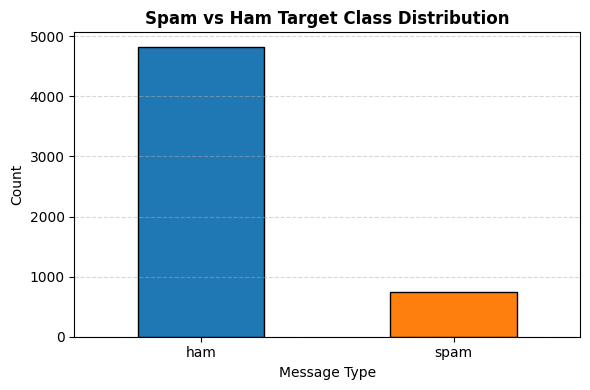

In [24]:
# ======================================================================
# PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)
# ======================================================================
import matplotlib.pyplot as plt

# Plotting Class Distribution
plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar", color=["#1f77b4", "#ff7f0e"], edgecolor="k")
plt.title("Spam vs Ham Target Class Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Message Type", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

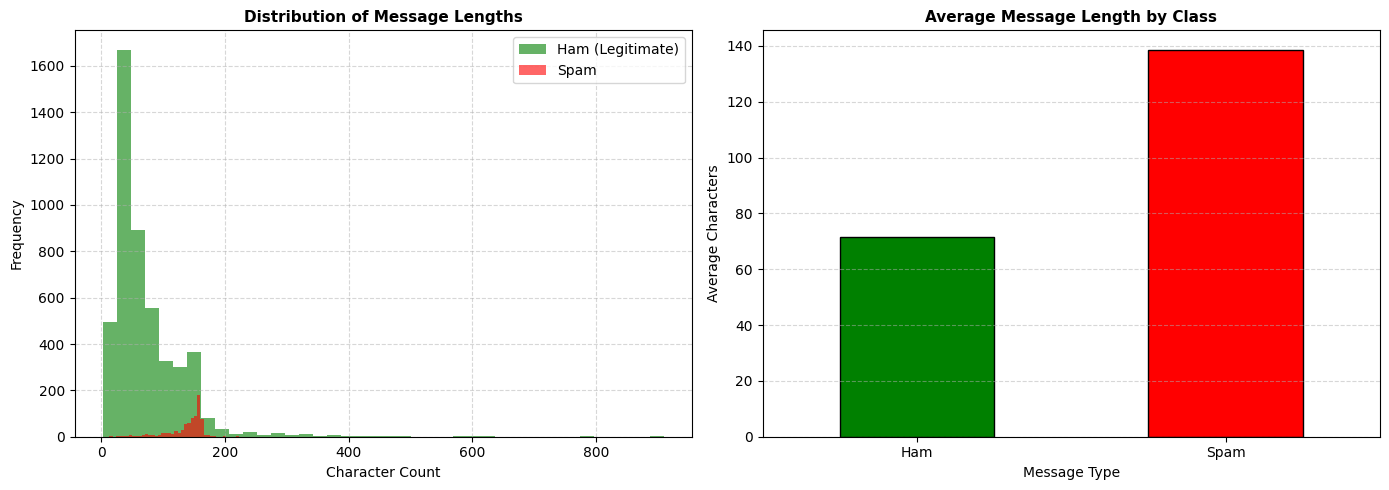

=== Summary Statistics (Message Length) ===
label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64


In [25]:
# Feature Engineering: Analyzing message lengths
df["message_length"] = df["message"].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Length distribution histogram
df[df["label"] == "ham"]["message_length"].hist(
    bins=40, alpha=0.6, label="Ham (Legitimate)", ax=axes[0], color="g"
)
df[df["label"] == "spam"]["message_length"].hist(
    bins=40, alpha=0.6, label="Spam", ax=axes[0], color="r"
)
axes[0].set_title("Distribution of Message Lengths", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Average length bar plot
mean_lengths = df.groupby("label")["message_length"].mean()
mean_lengths.plot(kind="bar", color=["g", "r"], edgecolor="k", ax=axes[1])
axes[1].set_title("Average Message Length by Class", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Message Type")
axes[1].set_ylabel("Average Characters")
axes[1].set_xticklabels(["Ham", "Spam"], rotation=0)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("=== Summary Statistics (Message Length) ===")
print(mean_lengths)

In [26]:
# ======================================================================
# PHASE 3: MODEL DEVELOPMENT & VALIDATION
# ======================================================================
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier

# Prepare target vector and feature space cleanly
df_model = df[["message", "label"]].dropna().copy()
df_model["message"] = df_model["message"].astype(str)
df_model["label"] = df_model["label"].str.strip().str.lower()

X = df_model["message"]
y = df_model["label"]

# Define the initial Baseline Stratified Cross-Validation structure
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

=== Classification Report (training data) ===
              precision    recall  f1-score   support

         ham     0.9998    1.0000    0.9999      4825
        spam     1.0000    0.9987    0.9993       747

    accuracy                         0.9998      5572
   macro avg     0.9999    0.9993    0.9996      5572
weighted avg     0.9998    0.9998    0.9998      5572



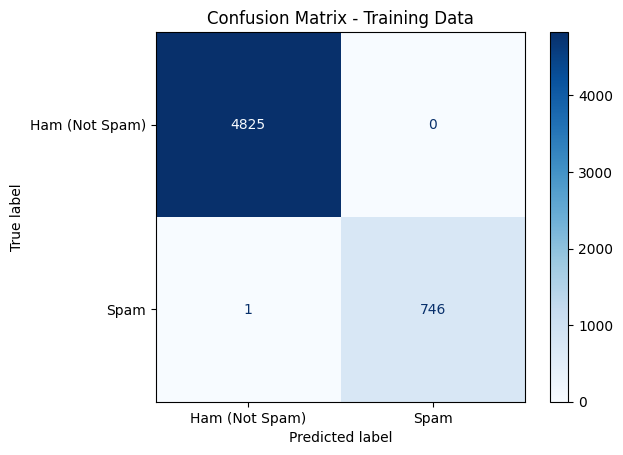

In [27]:

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Predict on the dataset for a demonstration
y_pred = model.predict(X)

# Print detailed metrics for spam and ham
print("=== Classification Report (training data) ===")
print(classification_report(y, y_pred, digits=4))

# Plot confusion matrix
cm = confusion_matrix(y, y_pred, labels=["ham", "spam"])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham (Not Spam)", "Spam"]
)

display.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Training Data")
plt.show()


Training messages: 4457
Testing messages: 1115

Test accuracy: 0.9525

Classification Report:
              precision    recall  f1-score   support

         ham     0.9780    0.9669    0.9724       966
        spam     0.8000    0.8591    0.8285       149

    accuracy                         0.9525      1115
   macro avg     0.8890    0.9130    0.9004      1115
weighted avg     0.9542    0.9525    0.9532      1115



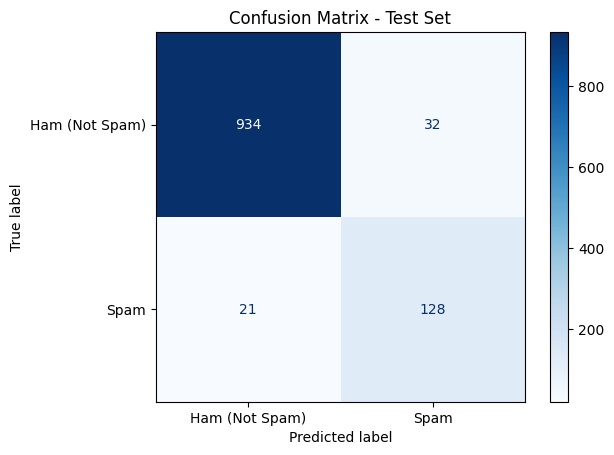

In [28]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    df["message"].astype(str),
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

# Create a fresh pipeline to prevent data leakage
test_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=5000
    )),
    ("tree", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# Train on training data only
test_model.fit(X_train, y_train)

# Evaluate on unseen test data
y_pred = test_model.predict(X_test)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))
print("\nTest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=["ham", "spam"],
    display_labels=["Ham (Not Spam)", "Spam"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix - Test Set")
plt.show()


In [29]:

import joblib

joblib.dump(test_model, "/content/spam_decision_tree_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [30]:
# ======================================================================
# PHASE 6: INTERACTIVE DEMO (PRODUCTION SIMULATION)
# ======================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

message_input = widgets.Textarea(
    value="Congratulations! You won a free prize. Claim now!",
    placeholder="Type a message to check...",
    description="Message:",
    layout=widgets.Layout(width="90%", height="100px")
)

check_button = widgets.Button(
    description="Check Message",
    button_style="success"
)

output = widgets.Output()

def check_message(button):
    with output:
        clear_output()
        text = message_input.value.strip()

        if not text:
            print("Please enter a message first.")
            return

        # Use our best optimized model for predictions
        prediction = best_model.predict([text])[0]
        probabilities = best_model.predict_proba([text])[0]
        class_idx = list(best_model.classes_).index(prediction)
        confidence = probabilities[class_idx] * 100

        print(f"Prediction: {prediction.upper()}")
        print(f"Confidence: {confidence:.2f}%")
        print(f"Message Evaluated: \"{text}\"")

check_button.on_click(check_message)

display(message_input, check_button, output)

Textarea(value='Congratulations! You won a free prize. Claim now!', description='Message:', layout=Layout(heig…

Button(button_style='success', description='Check Message', style=ButtonStyle())

Output()

### Professional Enhancement: Comparing Models and Hyperparameter Tuning
Below, we compare the original `DecisionTreeClassifier` with `MultinomialNB` and `LogisticRegression`. We will also use `GridSearchCV` to optimize the best candidate pipeline.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import numpy as np

# Define candidate pipelines
pipelines = {
    "Decision Tree": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
        ("clf", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]),
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
        ("clf", MultinomialNB())
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42))
    ])
}

# Evaluate and compare baselines using Cross-Validation
print("=== Baseline Model Comparison (5-Fold CV F1-Macro) ===")
for name, pipe in pipelines.items():
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    mean_f1 = np.mean(cv_results["test_score"])
    std_f1 = np.std(cv_results["test_score"])
    print(f"{name:20}: Mean F1-Macro = {mean_f1:.4f} ± {std_f1:.4f}")

=== Baseline Model Comparison (5-Fold CV F1-Macro) ===
Decision Tree       : Mean F1-Macro = 0.9052 ± 0.0072
Naive Bayes         : Mean F1-Macro = 0.9364 ± 0.0145
Logistic Regression : Mean F1-Macro = 0.9606 ± 0.0032


Now, we will perform a systematic Grid Search on the top performing baseline pipeline (typically Logistic Regression or TF-IDF optimized pipeline) to tune the TF-IDF feature range and classification parameters.

In [32]:
# Setting up Grid Search for the Logistic Regression pipeline
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_df": [0.9, 0.95],
    "clf__C": [0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    pipelines["Logistic Regression"],
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Optimizing Logistic Regression pipeline...")
grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)

print("\n=== Optimized Model Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, digits=4))

Optimizing Logistic Regression pipeline...

Best parameters found:
{'clf__C': 10.0, 'tfidf__max_df': 0.9, 'tfidf__ngram_range': (1, 1)}

=== Optimized Model Classification Report (Test Set) ===
              precision    recall  f1-score   support

         ham     0.9866    0.9886    0.9876       966
        spam     0.9252    0.9128    0.9189       149

    accuracy                         0.9785      1115
   macro avg     0.9559    0.9507    0.9533      1115
weighted avg     0.9784    0.9785    0.9784      1115



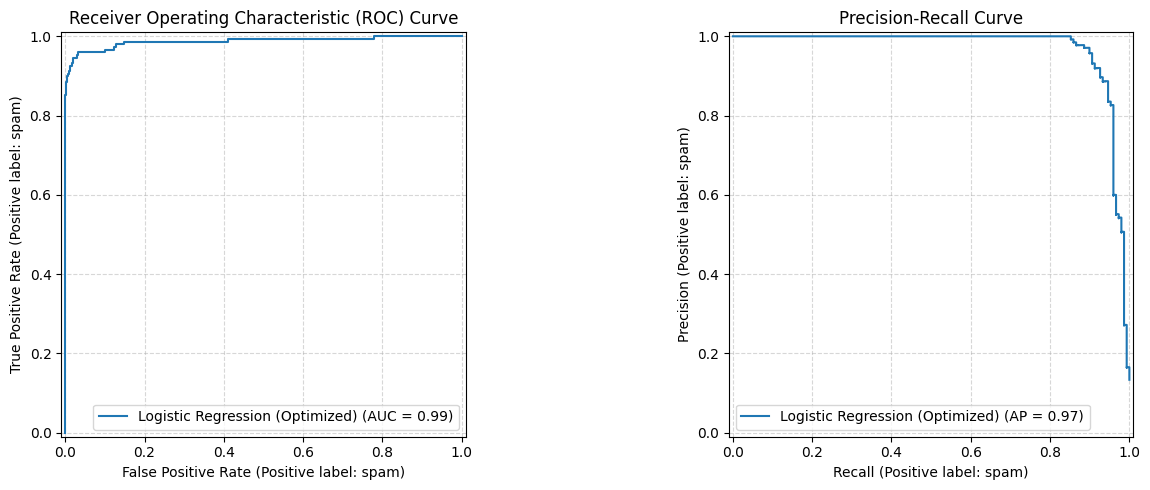

In [33]:
# Plot advanced evaluation metrics: ROC and Precision-Recall curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1, name="Logistic Regression (Optimized)")
ax1.set_title("Receiver Operating Characteristic (ROC) Curve")
ax1.grid(True, linestyle="--", alpha=0.5)

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2, name="Logistic Regression (Optimized)")
ax2.set_title("Precision-Recall Curve")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()